In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import camb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


GetDist Version: 1.5.4, Matplotlib version: 3.9.2


In [30]:
# Loading samples
# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.3, 
                    'smooth_scale_2D': 0.6,
                    'smooth_scale_1D': 0.6,
                    }    

# LCDM:
chain_lcdm = '/home/andrewcats/tesi_magistrale/lcdm/planck_all/1_lcdm_planck_desidr2_des'
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

# W0WA:
chain_w0wa = '/home/andrewcats/tesi_magistrale/w0wacdm/all_planck/1_w0wa_planck_desidr2_des'
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

#EFT_exp 2:
chain_exp2 = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/second_attempt', '1_EXP_planck_desidr2_des')
samples_exp2 = getdist.mcsamples.loadMCSamples(file_root=chain_exp2, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp2 = [param.name for param in samples_exp2.paramNames.names]
print(param_names_exp2)

#EFT_cos:
chain_cos = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_cosine/lcdm_eft_cos/planck_all', '1_COS_planck_desidr2_des')
samples_cos = getdist.mcsamples.loadMCSamples(file_root=chain_cos, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_cos = [param.name for param in samples_cos.paramNames.names]
print(param_names_cos)

/home/andrewcats/tesi_magistrale/lcdm/planck_all/1_lcdm_planck_desidr2_des.1.txt
/home/andrewcats/tesi_magistrale/lcdm/planck_all/1_lcdm_planck_desidr2_des.2.txt
/home/andrewcats/tesi_magistrale/lcdm/planck_all/1_lcdm_planck_desidr2_des.3.txt
/home/andrewcats/tesi_magistrale/lcdm/planck_all/1_lcdm_planck_desidr2_des.4.txt
Removed 0.3 as burn in
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop

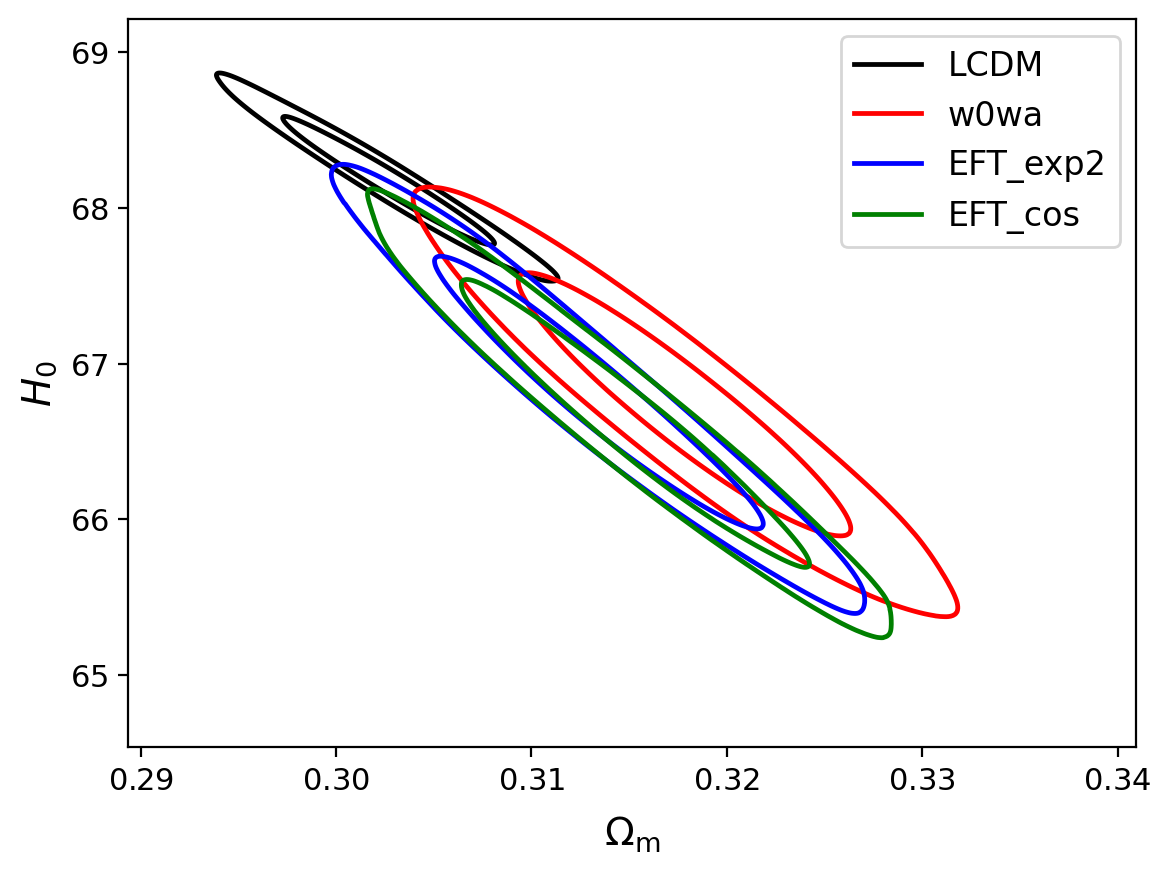

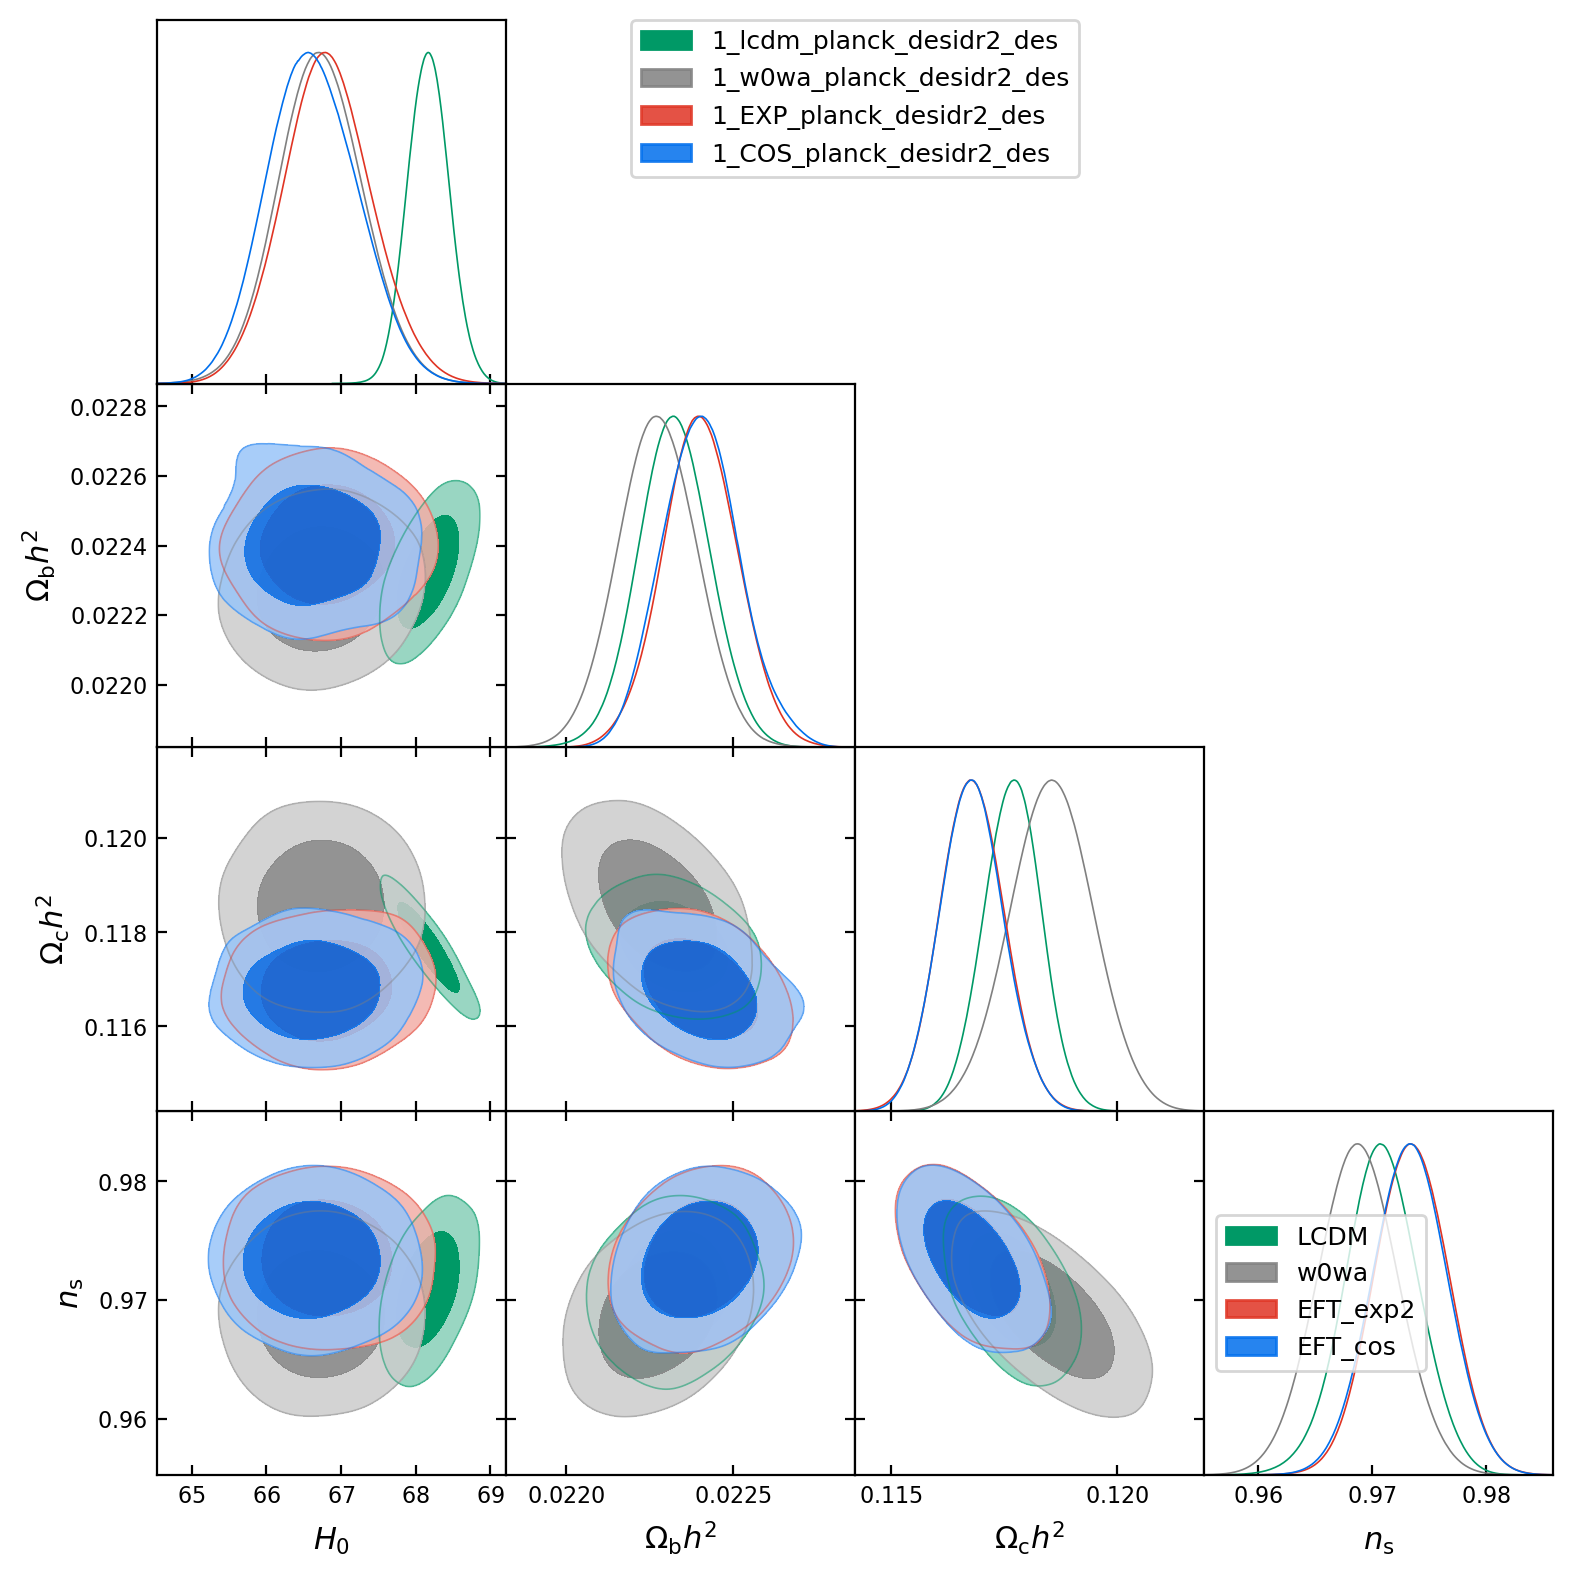

In [31]:
# Comparing 3 samples in the same plot
# lcdm vs w0wa vs exp
samples = [samples_lcdm, samples_w0wa, samples_exp2, samples_cos]
g = plots.get_single_plotter()
g.plot_2d(samples, ['omegam', 'H0'])
g.add_legend(['LCDM', 'w0wa', 'EFT_exp2', 'EFT_cos'])

g1 = plots.get_subplot_plotter()
g1.triangle_plot(samples, ['H0', 'ombh2', 'omch2', 'ns'], filled=True)
g1.add_legend(['LCDM', 'w0wa', 'EFT_exp2', 'EFT_cos'])



((np.float64(-0.9786980670162059), np.float64(-0.5470615129837941)),
 (np.float64(-1.6387231538514546), np.float64(0.09844137385145466)))

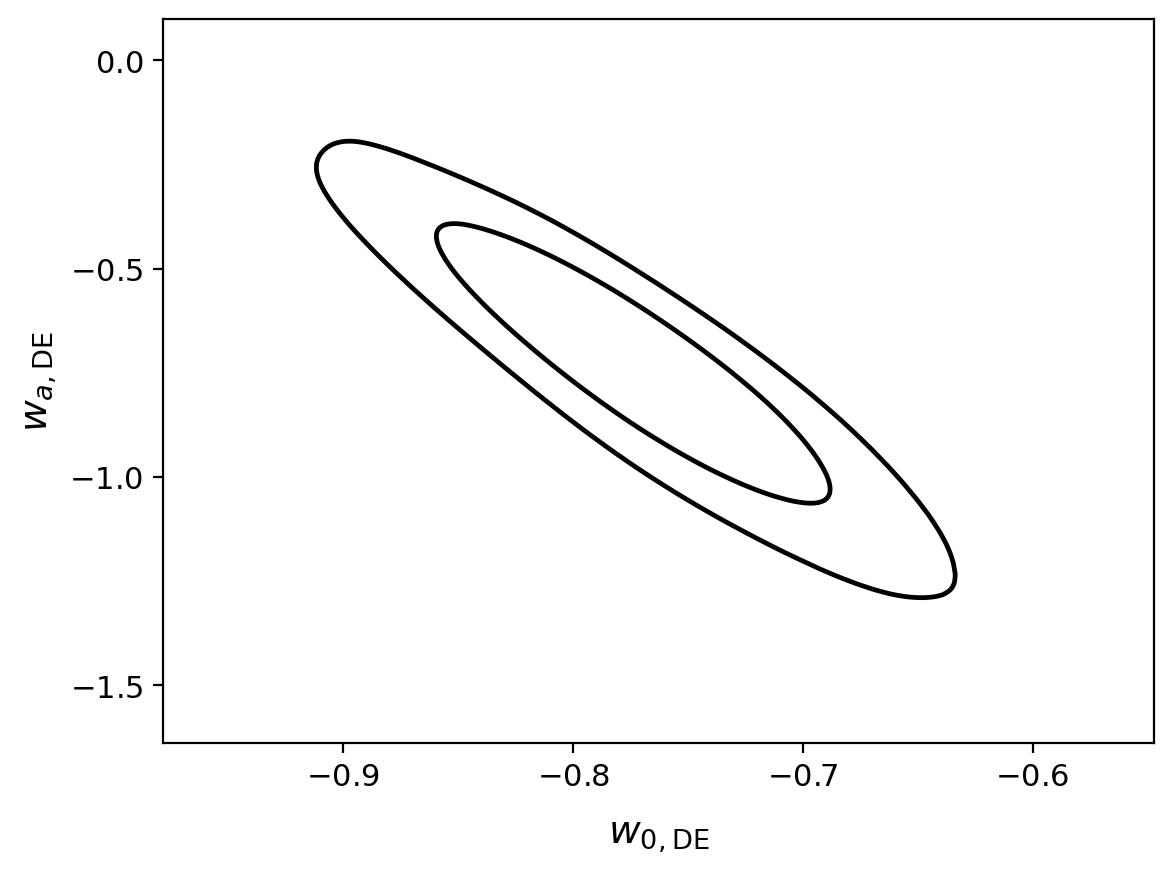

In [32]:
# plot w0, wa
g = plots.get_single_plotter()
g.plot_2d(samples_w0wa, ['w', 'wa'])

((0.001, np.float64(2.5340769046711156)), (1.001, 10.0))

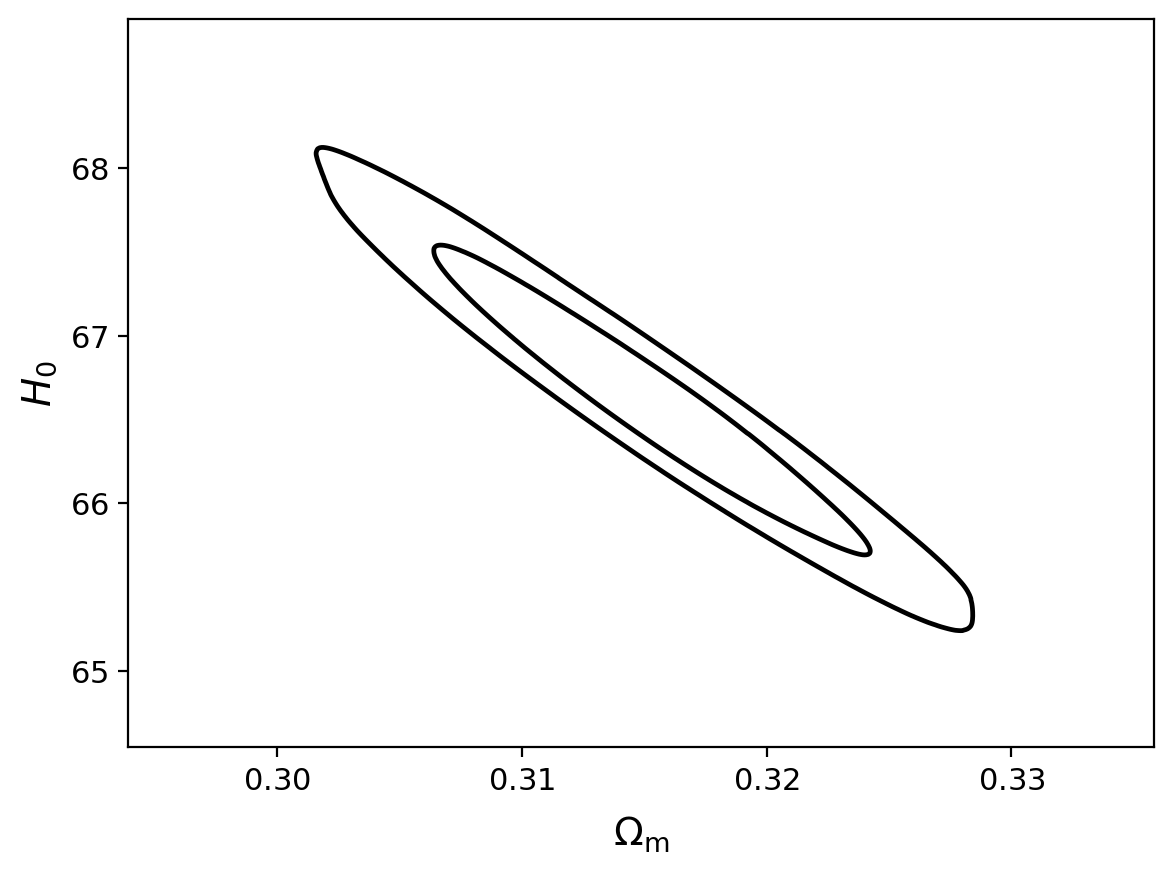

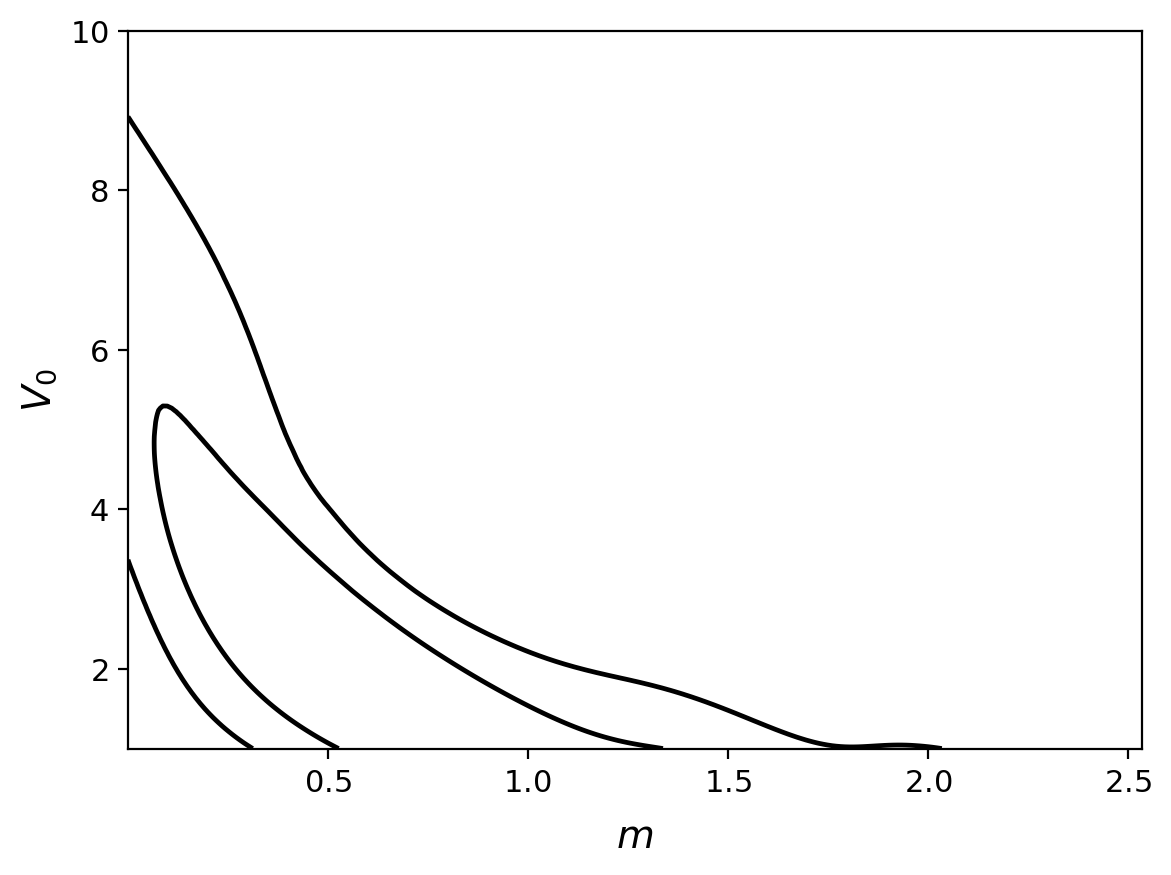

In [33]:
g = plots.get_single_plotter()
g.plot_2d(samples_cos, ['omegam', 'H0'])
#g.add_legend(['LCDM', 'w0wa', 'EFT_exp2', 'EFT_cos'])

g = plots.get_single_plotter()
g.plot_2d(samples_cos, ['m', 'V0'])
#g.add_legend(['LCDM', 'w0wa', 'EFT_exp2', 'EFT_cos'])

### Find parameter of EFTCAMB
**Remember**:
A **confidence interval** tells you the range of values that are most compatible with your data, given a statistical model. 

For example, in the case of contour plot:

The inner (darker) contour corresponds to the 68% confidence region

The outer (lighter) contour corresponds to the 95% confidence region

(In a few words the meaning is: If I repeated this experiment many times, about 68% of the intervals I compute would contain the true value of the parameter.)

EFT Lambda:
Mean = 0.7754000951177936
68% CL lower = 0.6540224930123847
68% CL upper = 0.9586263841353388
95% CL lower = 0.420078996757396
95% CL upper = 1.0876734741396357


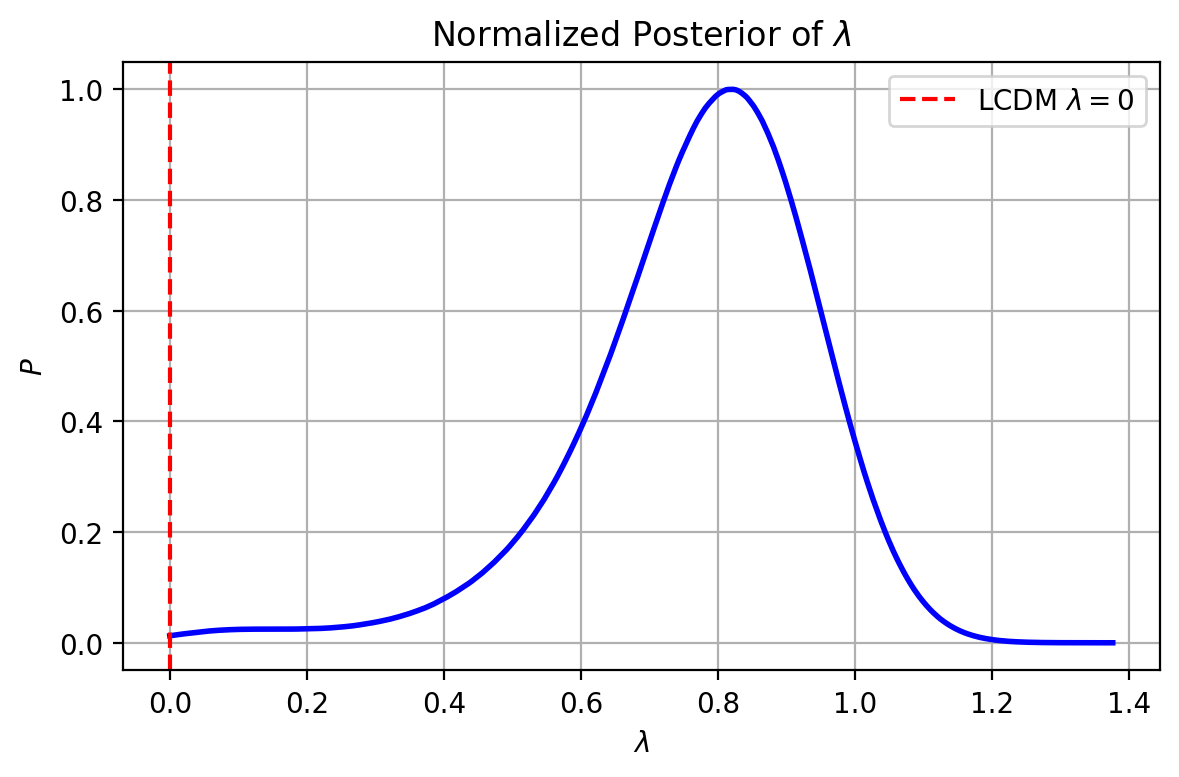

In [34]:
# Get the MargeStats object
marg_stats = samples_exp2.getMargeStats()

# Get statistics for the parameter 'EFT_lambda'
lambda_stats = marg_stats.parWithName('EFT_lambda')

print("EFT Lambda:")
print("Mean =", lambda_stats.mean)
print("68% CL lower =", lambda_stats.limits[0].lower)
print("68% CL upper =", lambda_stats.limits[0].upper)
print("95% CL lower =", lambda_stats.limits[1].lower)
print("95% CL upper =", lambda_stats.limits[1].upper)

#Plot
density = samples_exp2.get1DDensity('EFT_lambda')

# x: parameter values
lambda_vals = density.x

# y: marginalized posterior values 
P_lambda = density.P

# Normalize to peak
P_lambda_norm = P_lambda / np.max(P_lambda)


plt.figure(figsize=(6, 4))
plt.plot(lambda_vals, P_lambda_norm, color='blue', lw=2)
# add vertical line in lambda = 0 for the lambdaCDM: 
plt.axvline(x=0, color='red', linestyle='--', label='LCDM $\lambda=0$')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$P$')
plt.title('Normalized Posterior of $\lambda$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### $\Delta \phi$

In [35]:

# Extract EFT_lambda and Omega_lambda samples
lambda_samples = samples_exp2.samples[:, samples_exp2.index['EFT_lambda']]
omega_lambda = samples_exp2.samples[:, samples_exp2.index['omega_de']]

# Compute Delta_phi for each sample
sqrt_omega = np.sqrt(omega_lambda)
ln_term = np.log((1 + sqrt_omega) / (1 - sqrt_omega))
delta_phi_samples = (lambda_samples / 3.0) * (ln_term / sqrt_omega - 2)

# Add Δφ as a derived parameter to the MCSamples object
samples_exp2.addDerived(
    delta_phi_samples,
    name='delta_phi',
    label=r'\Delta\phi'
)

# Update internal stats (mean, limits, etc.)
samples_exp2.updateBaseStatistics()


In [36]:
# Get marginal statistics for all parameters
stats = samples_exp2.getMargeStats()

# Extract statistics for delta_phi
dphi_stats = stats.parWithName('delta_phi')

print("Delta phi:")
print("Mean =", dphi_stats.mean)
print("68% CL lower =", dphi_stats.limits[0].lower)
print("68% CL upper =", dphi_stats.limits[0].upper)
print("95% CL lower =", dphi_stats.limits[1].lower)
print("95% CL upper =", dphi_stats.limits[1].upper)

Delta phi:
Mean = 0.22097242087738828
68% CL lower = 0.18960122907878896
68% CL upper = 0.2706517755945494
95% CL lower = 0.12469082551117175
95% CL upper = 0.303946537154211


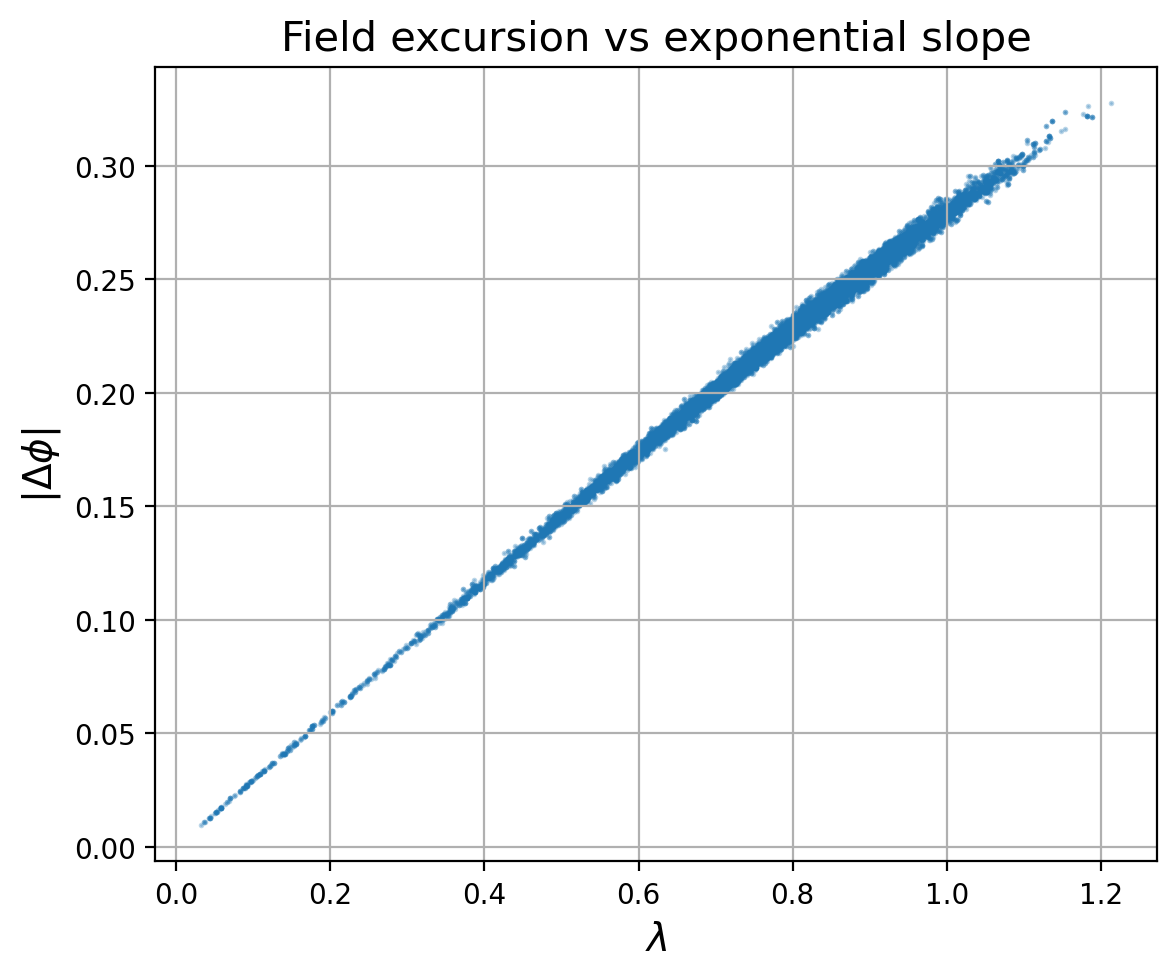

In [37]:
plt.figure(figsize=(6, 5))
plt.scatter(lambda_samples, delta_phi_samples, s=1, alpha=0.3)
plt.xlabel(r"$\lambda$", fontsize=14)
plt.ylabel(r"$|\Delta\phi|$", fontsize=14)
plt.title(r"Field excursion vs exponential slope", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Text(34.4429711235894, 0.5, '$|\\Delta\\phi|$')

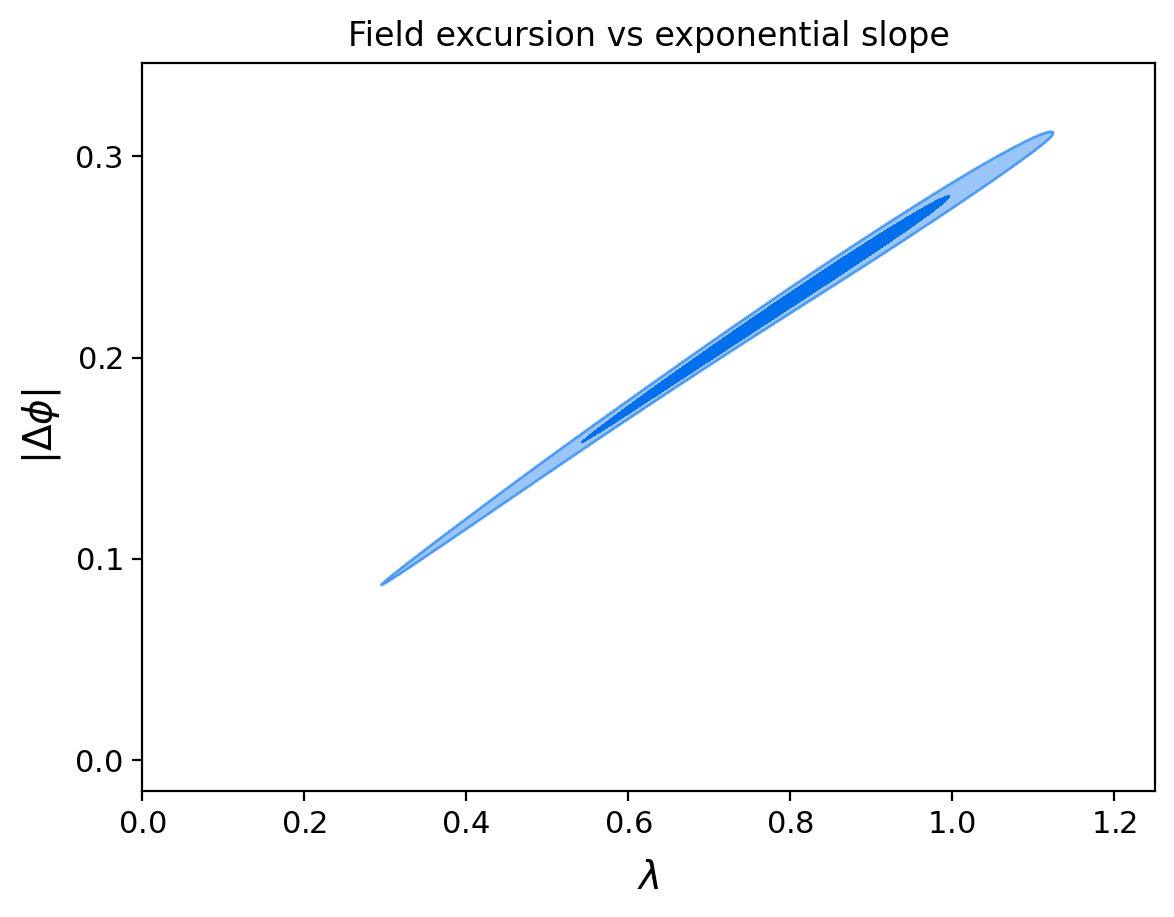

In [38]:
g = plots.get_single_plotter()
g.plot_2d(samples_exp2, ['EFT_lambda', 'delta_phi'], filled=True)
#title:

g.subplots[0][0].set_title(r'Field excursion vs exponential slope')
# x and y axes:
g.subplots[0][0].set_xlabel(r"$\lambda$")
g.subplots[0][0].set_ylabel(r'$|\Delta\phi|$')


# COSINE

m:
Mean = 0.5284415701444604
68% CL lower = 0.043194522633243894
68% CL upper = 0.6477874424793276
95% CL lower = 0.001
95% CL upper = 1.3541079


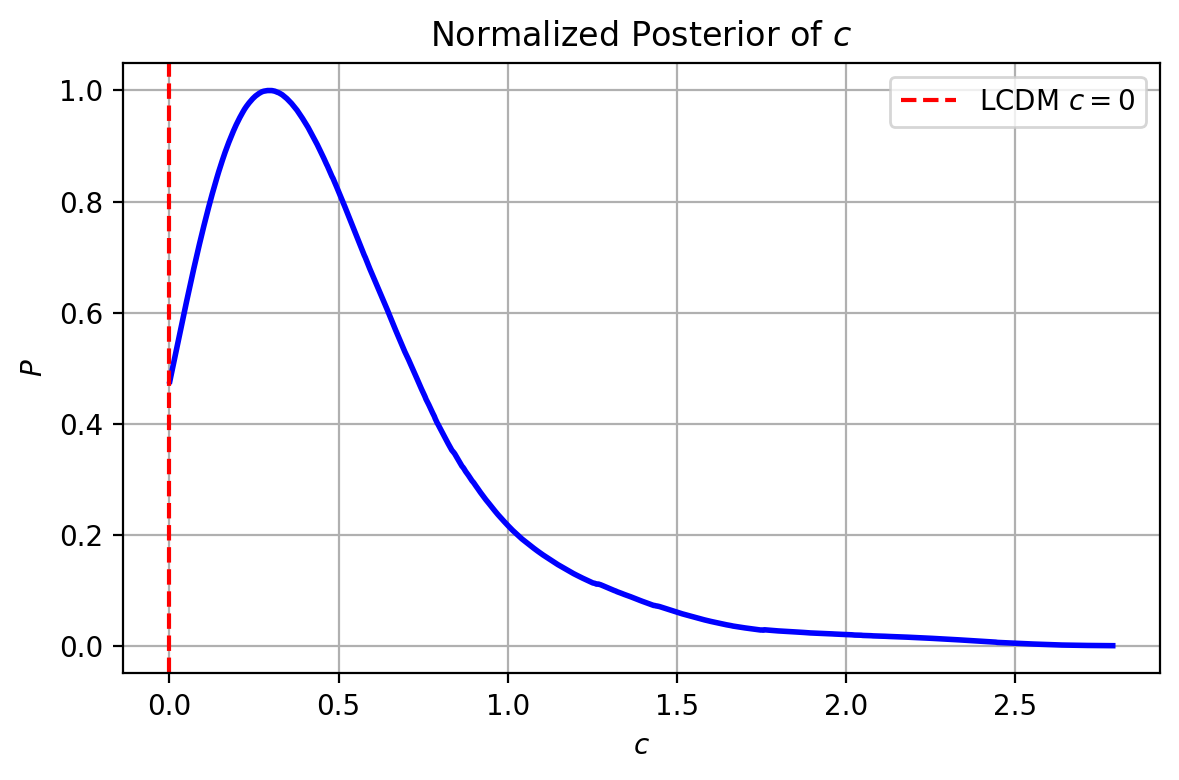

In [39]:
# Get the MargeStats object
marg_stats_m = samples_cos.getMargeStats()

# Get statistics for the parameter 'EFT_lambda'
m_stats = marg_stats_m.parWithName('m')

print("m:")
print("Mean =", m_stats.mean)
print("68% CL lower =", m_stats.limits[0].lower)
print("68% CL upper =", m_stats.limits[0].upper)
print("95% CL lower =", m_stats.limits[1].lower)
print("95% CL upper =", m_stats.limits[1].upper)

#Plot
density = samples_cos.get1DDensity('m')

# x: parameter values
m_vals = density.x

# y: marginalized posterior values 
P_m = density.P

# Normalize to peak
P_m_norm = P_m / np.max(P_m)


plt.figure(figsize=(6, 4))
plt.plot(m_vals, P_m_norm, color='blue', lw=2)
# add vertical line in lambda = 0 for the lambdaCDM: 
plt.axvline(x=0, color='red', linestyle='--', label='LCDM $c=0$')
plt.xlabel(r'$c$')
plt.ylabel(r'$P$')
plt.title('Normalized Posterior of $c$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
'''
# Extract m to compute m^2:
m_samples = samples_cos.samples[:, samples_cos.index['m']]

m2_samples = m_samples ** 2

# Add Δφ as a derived parameter to the MCSamples object
samples_cos.addDerived(
    m2_samples,
    name='m_2',
    label=r'm^2'
)

# Update internal stats (mean, limits, etc.)
samples_cos.updateBaseStatistics()
'''

"\n# Extract m to compute m^2:\nm_samples = samples_cos.samples[:, samples_cos.index['m']]\n\nm2_samples = m_samples ** 2\n\n# Add Δφ as a derived parameter to the MCSamples object\nsamples_cos.addDerived(\n    m2_samples,\n    name='m_2',\n    label=r'm^2'\n)\n\n# Update internal stats (mean, limits, etc.)\nsamples_cos.updateBaseStatistics()\n"

In [41]:
# E' sbagliato perche non so cosa mettere al posto di lambda quando calcolo delta_phi
# Extract EFT_lambda and Omega_lambda samples
m_samples = samples_cos.samples[:, samples_cos.index['m']]
omega_lambda_cos = samples_cos.samples[:, samples_cos.index['omega_de']]

# Compute Delta_phi for each sample
sqrt_omega_cos = np.sqrt(omega_lambda_cos)
ln_term_cos = np.log((1 + sqrt_omega_cos) / (1 - sqrt_omega_cos))
delta_phi_samples_cos = (m_samples / 3.0) * (ln_term_cos / sqrt_omega_cos - 2)  #--> qui m_samples è sbagliato, ma non so cosa mettere al posto di lambda!!!

# Add Δφ as a derived parameter to the MCSamples object
samples_cos.addDerived(
    delta_phi_samples_cos,
    name='delta_phi_cos',
    label=r'\Delta\phi'
)

# Update internal stats (mean, limits, etc.)
samples_cos.updateBaseStatistics()


In [42]:
# Get marginal statistics for all parameters
stats_cos = samples_cos.getMargeStats()

# Extract statistics for delta_phi
dphi_stats_m = stats_cos.parWithName('delta_phi_cos')

print("Delta phi con cos:")
print("Mean =", dphi_stats.mean)
print("68% CL lower =", dphi_stats_m.limits[0].lower)
print("68% CL upper =", dphi_stats_m.limits[0].upper)
print("95% CL lower =", dphi_stats_m.limits[1].lower)
print("95% CL upper =", dphi_stats_m.limits[1].upper)

# Update internal stats (mean, limits, etc.)
samples_exp2.updateBaseStatistics()

Delta phi con cos:
Mean = 0.22097242087738828
68% CL lower = 0.030008635155672037
68% CL upper = 0.21057897786740098
95% CL lower = -0.03157958254720568
95% CL upper = 0.3957462110671082


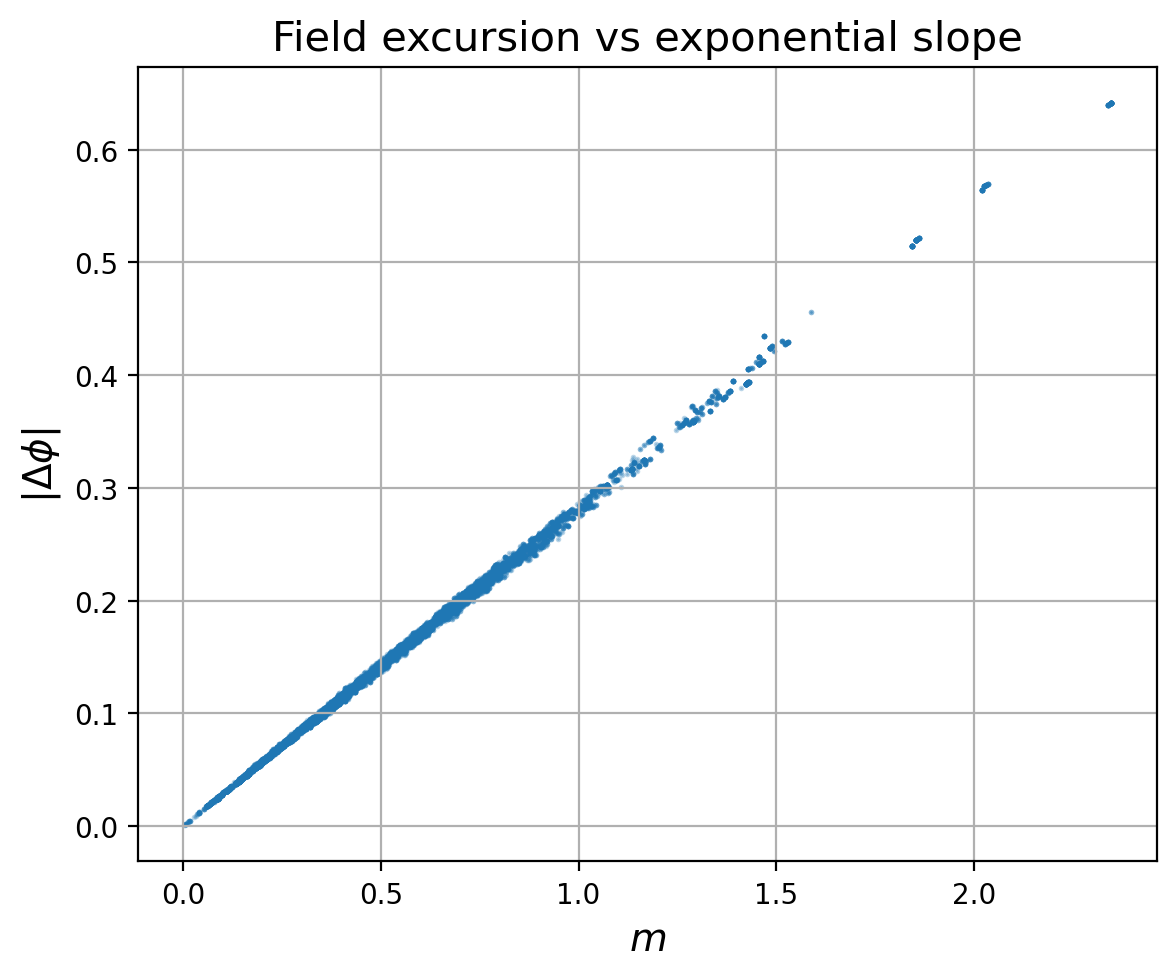

In [43]:
plt.figure(figsize=(6, 5))
plt.scatter(m_samples, delta_phi_samples_cos, s=1, alpha=0.3)
plt.xlabel(r"$m$", fontsize=14)
plt.ylabel(r"$|\Delta\phi|$", fontsize=14)
plt.title(r"Field excursion vs exponential slope", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Text(34.3648461235894, 0.5, '$|\\Delta\\phi|$')

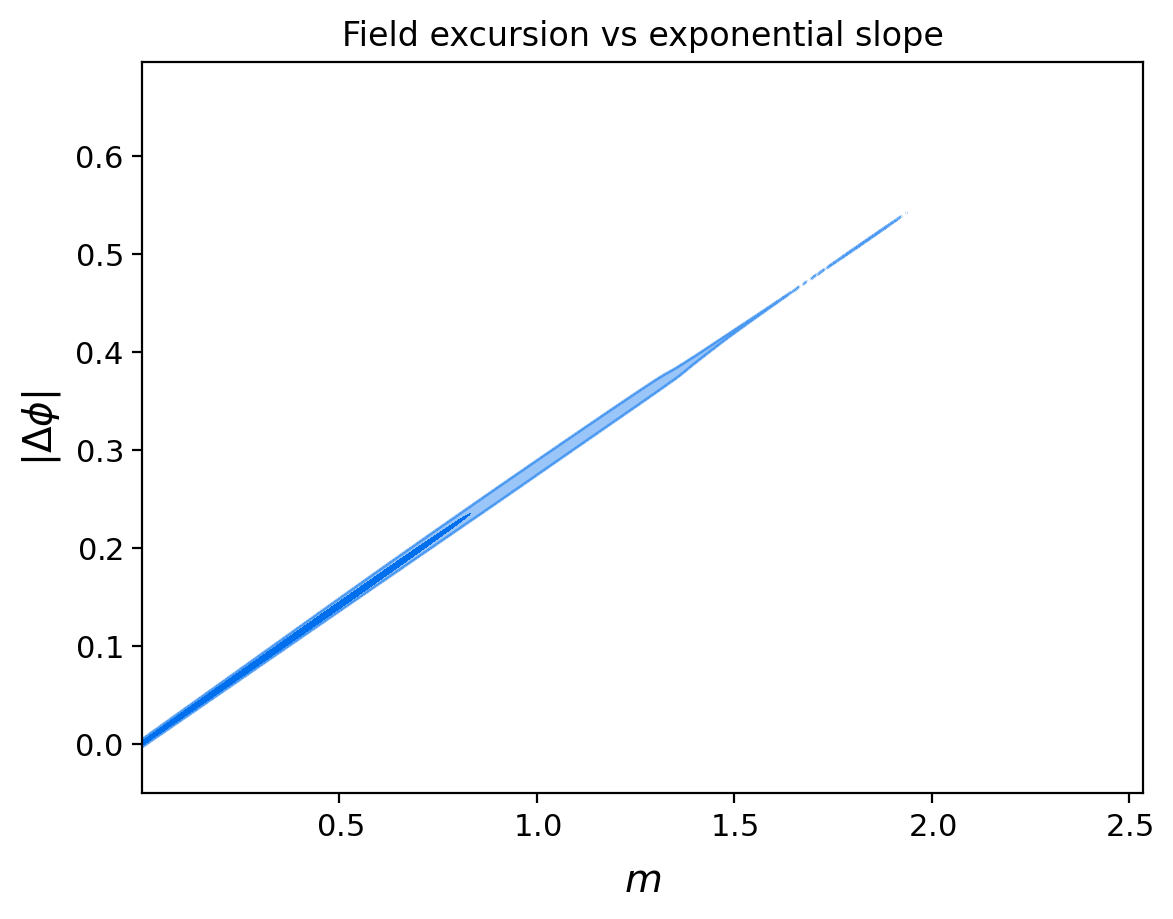

In [44]:
g = plots.get_single_plotter()
g.plot_2d(samples_cos, ['m', 'delta_phi_cos'], filled=True)
#title:

g.subplots[0][0].set_title(r'Field excursion vs exponential slope')
# x and y axes:
g.subplots[0][0].set_xlabel(r"$m$")
g.subplots[0][0].set_ylabel(r'$|\Delta\phi|$')


In [45]:
# fare anche i graifici che ci sono su paper di raveri_vafa (usando lambda_eff) --> provare a mettere phi_i = 0
# fare anche i grafiic con c^2 ?? perche in realta i constraints sono su c^2 e non su c (che in realtà io nel codice sto chiamando m)

In [46]:
# Constraints on c^2
# Extract m to compute m^2:
m_samples = samples_cos.samples[:, samples_cos.index['m']]

m2_samples = m_samples ** 2

# check first values of m_samples and m2_samples
print("First 5 values of m_samples:", m_samples[:5])
print("First 5 values of m2_samples:", m2_samples[:5])

# Add Δφ as a derived parameter to the MCSamples object
samples_cos.addDerived(
    m2_samples,
    name='m_2',
    label=r'm^2'
)
# Update internal stats (mean, limits, etc.)
samples_cos.updateBaseStatistics()


First 5 values of m_samples: [0.97179508 0.90859917 0.90993119 0.93674596 0.93674596]
First 5 values of m2_samples: [0.94438568 0.82555245 0.82797477 0.87749299 0.87749299]


First 5 values of m_samples: [0.97179508 0.90859917 0.90993119 0.93674596 0.93674596]
First 5 values of m2_samples: [0.94438568 0.82555245 0.82797477 0.87749299 0.87749299]
c^2:
Mean = 0.43329786376241425
68% CL lower = -0.22337914558375555
68% CL upper = 0.6808153365743527
95% CL lower = -0.6576155043050192
95% CL upper = 1.778567399863562


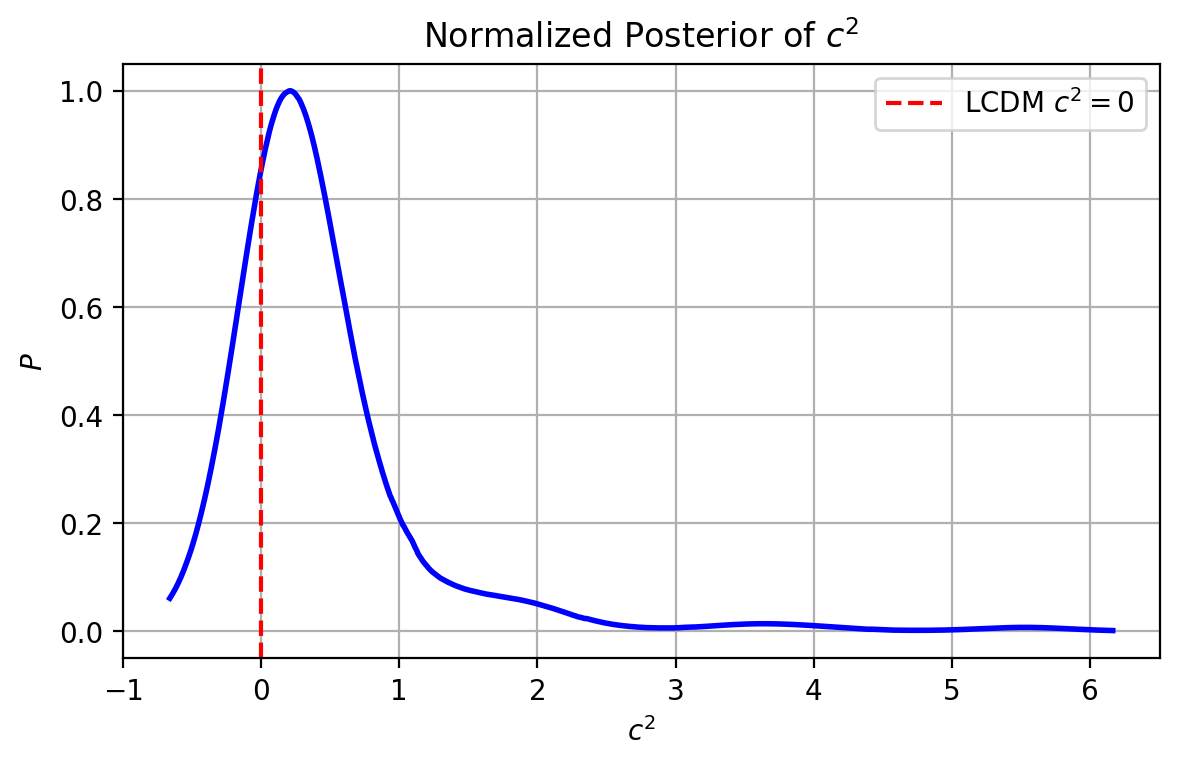

In [47]:
# check first values of m_samples and m2_samples
print("First 5 values of m_samples:", m_samples[:5])
print("First 5 values of m2_samples:", m2_samples[:5])

# Get the MargeStats object
marg_stats_c2 = samples_cos.getMargeStats()
# Get statistics for the parameter 'c^2'
c2_stats = marg_stats_c2.parWithName('m_2')
print("c^2:")
print("Mean =", c2_stats.mean)
print("68% CL lower =", c2_stats.limits[0].lower)
print("68% CL upper =", c2_stats.limits[0].upper)
print("95% CL lower =", c2_stats.limits[1].lower)
print("95% CL upper =", c2_stats.limits[1].upper)

#Plot
density_c2 = samples_cos.get1DDensity('m_2')
# x: parameter values
c2_vals = density_c2.x
# y: marginalized posterior values
P_c2 = density_c2.P

# Normalize to peak
P_c2_norm = P_c2 / np.max(P_c2)
plt.figure(figsize=(6, 4))
plt.plot(c2_vals, P_c2_norm, color='blue', lw=2)
# add vertical line in c^2 = 0 for the lambdaCDM:
plt.axvline(x=0, color='red', linestyle='--', label='LCDM $c^2=0$')
plt.xlabel(r'$c^2$')
plt.ylabel(r'$P$')
plt.title('Normalized Posterior of $c^2$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## BIC AND MCEVIDENCE METHOD

In [48]:
# Comparing models using BIC (Bayesian Information Criterion)
# BIC = -2*ln(L) + k*ln(n) where L = likelihood, k = number of parameters, n = number of data points
# Load chain data without headers

data_raw = np.loadtxt(os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/all_planck', '1_w0wa_planck_desidr2_des.1.txt'))

# Add number of extra columns at the end (you know them already)
n_params = len(samples_w0wa.paramNames.names)
print(n_params)
n_total_cols = data_raw.shape[1]
print(n_total_cols)
n_extra_cols = n_total_cols - n_params
print(n_extra_cols)

# Extract those column names
extra_cols = ['weight', 'minuslogpost', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']

# Create DataFrame
all_col_names = param_names_w0wa + extra_cols[:n_extra_cols]
print("Column names:", all_col_names)
df = pd.DataFrame(data_raw, columns=all_col_names)

# Compute loglike and logposterior
df["loglike"] = -0.5 * df["chi2"]
#df["logprior"] = -df["minuslogprior"]
#df["logpost"] = df["loglike"] + df["logprior"]

# Compute stats
max_loglike_w0wa = df["loglike"].max()
mean_loglike_w0wa = df["loglike"].mean()
complexity_w0wa = 2 * (mean_loglike_w0wa - max_loglike_w0wa)

print(f"Max loglike: {max_loglike_w0wa:.3f}")
print(f"Mean loglike: {mean_loglike_w0wa:.3f}")
print(f"Bayesian complexity (effective params): {complexity_w0wa:.3f}")
print(f"Number of samples: {len(df)}")

k_w0wa = len(samples_w0wa.paramNames.names)  # number of params
print(k_w0wa) # N.B: maybe this is not the number of parameters, but the number of columns in the data frame
n_w0wa = len(df)                             # number of data points (or samples?)

aic_w0wa = 2 * k_w0wa - 2 * max_loglike_w0wa
bic_w0wa = k_w0wa * np.log(n_w0wa) - 2 * max_loglike_w0wa

print(f"AIC: {aic_w0wa:.2f}")
print(f"BIC: {bic_w0wa:.2f}")


54
56
2
Column names: ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE', 'weight', 'minuslogpost']
Max loglike: -0.357
Mean loglike: -2.711
Bayesian complexity (effective params): -4.707
Number of samples: 10511
54
AIC: 108.71
BIC: 500.76


In [49]:
# Now for the model lcdm
data_raw_lcdm = np.loadtxt(os.path.join('/home/andrewcats/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des.1.txt'))
# Add number of extra columns at the end (you know them already)
n_params_lcdm = len(samples_lcdm.paramNames.names)
n_total_cols_lcdm = data_raw_lcdm.shape[1]
n_extra_cols_lcdm = n_total_cols_lcdm - n_params_lcdm
# Extract those column names 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2018_lowl.EE_sroll2', 'chi2__act_dr6_cmbonly.PlanckActCut']
extra_cols_lcdm = ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
# Create DataFrame
all_col_names_lcdm = param_names_lcdm + extra_cols_lcdm[:n_extra_cols_lcdm]
df_lcdm = pd.DataFrame(data_raw_lcdm, columns=all_col_names_lcdm)
# Compute loglike and logposterior
df_lcdm["loglike"] = -0.5 * df_lcdm["chi2"]
# Compute stats
max_loglike_lcdm = df_lcdm["loglike"].max()
mean_loglike_lcdm = df_lcdm["loglike"].mean()
complexity_lcdm = 2 * (mean_loglike_lcdm - max_loglike_lcdm)
print(f"Max loglike: {max_loglike_lcdm:.3f}")
print(f"Mean loglike: {mean_loglike_lcdm:.3f}")
print(f"Bayesian complexity (effective params): {complexity_lcdm:.3f}")
print(f"Number of samples: {len(df_lcdm)}")

k_lcdm = len(samples_lcdm.paramNames.names)      # number of params
n_lcdm = len(df_lcdm)                            # number of data points (or samples?)
aic_lcdm = 2 * k_lcdm - 2 * max_loglike_lcdm
bic_lcdm = k_lcdm * np.log(n_lcdm) - 2 * max_loglike_lcdm
print(f"AIC: {aic_lcdm:.2f}")
print(f"BIC: {bic_lcdm:.2f}")

Max loglike: 1.798
Mean loglike: -1.075
Bayesian complexity (effective params): -5.746
Number of samples: 18630
AIC: 100.40
BIC: 507.69


In [50]:
# Comparison between lcdm and w0wa models using deltalog(B) = log(B_w0wa) - log(B_lcdm)
log_bic_w0wa = np.log(bic_w0wa)
log_bic_lcdm = np.log(bic_lcdm)
delta_lob_bic = log_bic_w0wa - log_bic_lcdm
print(f"Delta log(BIC): {delta_lob_bic:.3f}")
# Interpretation of the results
# If delta log(BIC) > 0, then the model with the lower BIC is preferred
# If delta log(BIC) < 0, then the model with the higher BIC is preferred
# If |delta log(BIC)| > 10, then the model with the lower BIC is strongly preferred
# If |delta log(BIC)| < 2, then the models are equivalent
# If 2 < |delta log(BIC)| < 10, then the model with the lower BIC is preferred

Delta log(BIC): -0.014


### MCEVIDENCE

In [51]:
'''
# Create a range file
ranges_text_exp = """\
logA 1.61 3.91
ns 0.8 1.2
ombh2 0.005 0.1
omch2 0.001 0.99
EFT_lambda 0 10
tau 0.01 0.8
H0 20 100
"""

with open("/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/mcevidence/1_EXP_planck_desidr2_des.ranges", "w") as f:
    f.write(ranges_text_exp)

print("✅ Fixed file written.")
'''
'''
# Create a range file for w0wacdm
ranges_text_w = """\
logA 1.61 3.91
ns 0.8 1.2
ombh2 0.005 0.1
omch2 0.001 0.99
w -3 1
wa -3 2
theta_MC_100 0.5 10
tau 0.01 0.8
H0 20 100
"""

with open("/home/andrewcats/tesi_magistrale/w0wacdm/all_planck/mcevidence/1_w0wa_planck_desidr2_des.ranges", "w") as f:
    f.write(ranges_text_w)
'''

'''
# Create a range file for lcdm
ranges_text_lcdm = """\
logA 1.61 3.91
ns 0.8 1.2
ombh2 0.005 0.1
omch2 0.001 0.99
tau 0.01 0.8
theta_MC_100 0.5 10
H0 20 100
"""
with open("/home/andrewcats/tesi_magistrale/lcdm/planck_all/mcevidence/1_lcdm_planck_desidr2_des.ranges", "w") as f:
    f.write(ranges_text_lcdm)
'''

'\n# Create a range file for lcdm\nranges_text_lcdm = """logA 1.61 3.91\nns 0.8 1.2\nombh2 0.005 0.1\nomch2 0.001 0.99\ntau 0.01 0.8\ntheta_MC_100 0.5 10\nH0 20 100\n"""\nwith open("/home/andrewcats/tesi_magistrale/lcdm/planck_all/mcevidence/1_lcdm_planck_desidr2_des.ranges", "w") as f:\n    f.write(ranges_text_lcdm)\n'

In [52]:
# exp
import subprocess

command = [
    "python",
    "/home/andrewcats/tesi_magistrale/MCEvidence/MCEvidence.py",
    "/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/mcevidence/1_EXP_planck_desidr2_des",
    #"--paramsfile", "/home/andrewcats/tesi_magistrale/w0wacdm/planckcut_all/paramnames/w0wacdm.paramnames",
    "--allparams"
]

result = subprocess.run(command, capture_output=True, text=True)

#print(result.stdout)
print(result.stderr)



/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
INFO:MCEvidence.py.params_info():1215     getting params info from COSMOMC file /home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/mcevidence/1_EXP_planck_desidr2_des.ranges
INFO:MCEvidence.py.get_prior_volume():1319     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1320     prior_volume=54.62919519999999
INFO:MCEvidence.py.get_prior_volume():1321     Number of params to use: ndim=7
INFO:MCEvidence.py.setup():142      Loading chain from /home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/pla

In [53]:
# w0wa
import subprocess

command = [
    "python",
    "/home/andrewcats/tesi_magistrale/MCEvidence/MCEvidence.py",
    "/home/andrewcats/tesi_magistrale/w0wacdm/all_planck/mcevidence/1_w0wa_planck_desidr2_des",
    #"--paramsfile", "/home/andrewcats/tesi_magistrale/w0wacdm/planckcut_all/paramnames/w0wacdm.paramnames",
    "--allparams"
]

result = subprocess.run(command, capture_output=True, text=True)

#print(result.stdout)
print(result.stderr)


/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
INFO:MCEvidence.py.params_info():1215     getting params info from COSMOMC file /home/andrewcats/tesi_magistrale/w0wacdm/all_planck/mcevidence/1_w0wa_planck_desidr2_des.ranges
INFO:MCEvidence.py.get_prior_volume():1319     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1320     prior_volume=1037.9547088
INFO:MCEvidence.py.get_prior_volume():1321     Number of params to use: ndim=9
INFO:MCEvidence.py.setup():142      Loading chain from /home/andrewcats/tesi_magistrale/w0wacdm/all_planck/mcevidence/1_w0wa_planck_desidr2_des
INFO:MCEvidence.py.load_f

In [54]:
# lcdm
import subprocess

command = [
    "python",
    "/home/andrewcats/tesi_magistrale/MCEvidence/MCEvidence.py",
    "/home/andrewcats/tesi_magistrale/lcdm/planck_all/mcevidence/1_lcdm_planck_desidr2_des",
    #"--paramsfile", "/home/andrewcats/tesi_magistrale/w0wacdm/planckcut_all/paramnames/w0wacdm.paramnames",
    "--allparams"
]

result = subprocess.run(command, capture_output=True, text=True)

#print(result.stdout)
print(result.stderr)

/home/andrewcats/anaconda3/envs/conda_andrea_g/lib/python3.9/site-packages/numpy/_core/getlimits.py:545: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
INFO:MCEvidence.py.params_info():1215     getting params info from COSMOMC file /home/andrewcats/tesi_magistrale/lcdm/planck_all/mcevidence/1_lcdm_planck_desidr2_des.ranges
INFO:MCEvidence.py.get_prior_volume():1319     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1320     prior_volume=51.89773543999999
INFO:MCEvidence.py.get_prior_volume():1321     Number of params to use: ndim=7
INFO:MCEvidence.py.setup():142      Loading chain from /home/andrewcats/tesi_magistrale/lcdm/planck_all/mcevidence/1_lcdm_planck_desidr2_des
INFO:MCEvidence.py.load_fr

### Results:

- $\Delta\ln B_{X,Y} < 1.1$: The models are **comparable**, with neither one clearly preferred.
- $1.1 < \Delta\ln B_{X,Y} < 3$: There is **weak evidence** favoring model X over model Y.
- $3 < \Delta\ln B_{X,Y} < 5$: There is **moderate evidence** favoring model X.
- $\Delta\ln B_{X,Y} > 5$: There is **strong evidence** favoring model X over model Y.

In [55]:
# Results for MCEVIDENCE:
# Compute delta_log_B:
lnB_LCDM = -16210.524938419152
lnB_W0WA = -16210.01222699493
lnB_EXP = -16199.172243359286


# Compute delta ln(B)
delta_lnB_WL = lnB_W0WA - lnB_LCDM
delta_lnB_EL = lnB_EXP - lnB_LCDM
delta_lnB_WE = lnB_W0WA - lnB_EXP

print(f"Delta ln(B) W0wa vs LCDM: {delta_lnB_WL:.3f}")
print(f"Delta ln(B) EFT_exp vs LCDM: {delta_lnB_EL:.3f}")
print(f"Delta ln(B) W0wa vs EFT_exp: {delta_lnB_WE:.3f}")

Delta ln(B) W0wa vs LCDM: 0.513
Delta ln(B) EFT_exp vs LCDM: 11.353
Delta ln(B) W0wa vs EFT_exp: -10.840


In [56]:
# Results for Tensiometer:
# Compute delta_log_B:
lnB_LCDM = -16243.3
lnB_W0WA = -16240.7
lnB_EXP = -16236.5


# Compute delta ln(B)
delta_lnB_WL = lnB_W0WA - lnB_LCDM
delta_lnB_EL = lnB_EXP - lnB_LCDM
delta_lnB_WE = lnB_W0WA - lnB_EXP

print(f"Delta ln(B) W0wa vs LCDM: {delta_lnB_WL:.3f}")
print(f"Delta ln(B) EFT_exp vs LCDM: {delta_lnB_EL:.3f}")
print(f"Delta ln(B) W0wa vs EFT_exp: {delta_lnB_WE:.3f}")

Delta ln(B) W0wa vs LCDM: 2.600
Delta ln(B) EFT_exp vs LCDM: 6.800
Delta ln(B) W0wa vs EFT_exp: -4.200


In [57]:
# con ACT e TENSIOMETER
# Compute delta_log_B:
lnB_LCDM = -1264.7
lnB_W0WA = -1268.3
lnB_EXP = -1262.3


# Compute delta ln(B)
delta_lnB_WL = lnB_W0WA - lnB_LCDM
delta_lnB_EL = lnB_EXP - lnB_LCDM
delta_lnB_WE = lnB_W0WA - lnB_EXP

print(f"ACT: Delta ln(B) W0wa vs LCDM: {delta_lnB_WL:.3f}")
print(f"ACT: Delta ln(B) EFT_exp vs LCDM: {delta_lnB_EL:.3f}")
print(f"ACT: Delta ln(B) W0wa vs EFT_exp: {delta_lnB_WE:.3f}")

ACT: Delta ln(B) W0wa vs LCDM: -3.600
ACT: Delta ln(B) EFT_exp vs LCDM: 2.400
ACT: Delta ln(B) W0wa vs EFT_exp: -6.000
